In [69]:
import numpy as np
import matplotlib.pyplot as plt
import scienceplots
plt.style.use(['science'])

from svm_primal import PrimalSVM
from svm_dual import DualSVM
from kernels import linear_kernel, make_rbf_kernel, make_polynomial_kernel, make_laplacian_kernel
from utils import accuracy, compute_primal_objective, get_support_vectors_primal, get_support_vectors_dual, test_linear

# Generate a simple 2D dataset
def make_toy_data(n=40, random_state=0):
    np.random.seed(random_state)
    # Two classes in 2D, mostly linearly separable
    X_class1 = np.random.randn(n,2) + np.array([+2.0, +2.0])
    X_class2 = np.random.randn(n,2) + np.array([-2.0, -2.0])
    X = np.vstack([X_class1, X_class2])
    y = np.array([+1]*n + [-1]*n)
    return X, y



def plot_decision_boundary_2D(model, X, y, title="", dual=False):
    fig, (ax, ax_learn) = plt.subplots(1,2 ,figsize=(12, 4))
    ax.scatter(X[y==+1,0], X[y==+1,1], label="+1 class", marker='o')
    ax.scatter(X[y==-1,0], X[y==-1,1], label="-1 class", marker='s')
    
    # Create mesh
    x_min, x_max = X[:,0].min()-1, X[:,0].max()+1
    y_min, y_max = X[:,1].min()-1, X[:,1].max()+1
    XX, YY = np.meshgrid(np.linspace(x_min, x_max, 200),
                         np.linspace(y_min, y_max, 200))
    grid_points = np.c_[XX.ravel(), YY.ravel()]
    
    # Predict
    if dual:
        Z = model.decision_function(grid_points)
    else:
        Z = model.decision_function(grid_points)
    
    Z = Z.reshape(XX.shape)
    
    ax.contour(XX, YY, Z, levels=[0.0], colors='k', linestyles=['-'])
    ax.contourf(XX, YY, Z, levels=[-1e9,0,1e9], alpha=0.2)
    
    ax.set_title(title)
    ax.legend()
    ax.set_xlabel("$x_1$")
    ax.set_ylabel("$x_2$")
    ax.grid()
    
    ax_learn.plot(model.obj_history, label="Objective function")
    ax_learn.set_title("Learning curve")
    ax_learn.set_xlabel("Iterations")
    ax_learn.set_ylabel("$\\mathcal{L}(\\mathbf{w}, b)$")
    ax_learn.axhline(0, color='k', linestyle='--')
    ax_learn.legend()
    ax_learn.grid()
    plt.show()

[PRIMAL] Accuracy: 1.0
[PRIMAL] Final objective: 0.5011522806500659
[PRIMAL] Margin: 0.9999971120910818
[PRIMAL] Weights: [0.70540739 0.70880617]
[PRIMAL] Bias: 0.0
[PRIMAL] #SupportVectors: 1
[PRIMAL] Support vectors indices: [43]


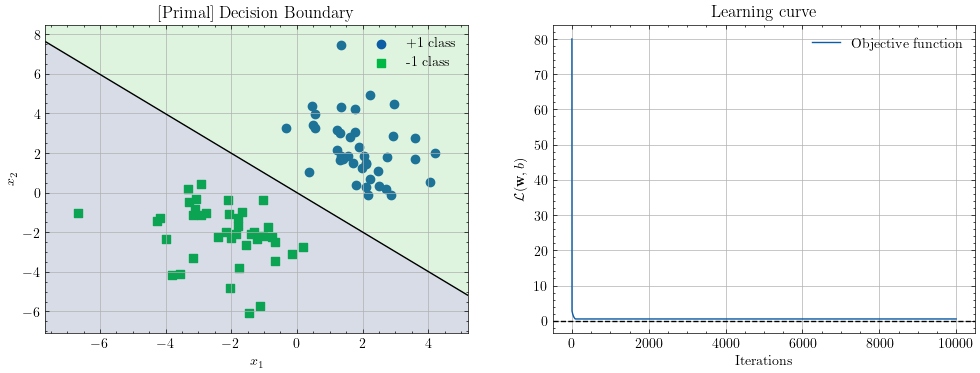

In [70]:

# 1) Primal SVM demonstration
w = np.array([1.0, 1.0])
b = 0.0
n = 40
margin = 1.0
X, y = test_linear(w=w, b=b, n_A=n, n_B=n, margin=margin, random_state=42, shape=(2, 2), noise=0.5)

primal_svm = PrimalSVM(C=1.0, max_iter=10_000, lr=1e-2, bb_steps=True, verbose=False)
primal_svm.fit(X, y)

pred_labels = primal_svm.predict(X)
acc = accuracy(y, pred_labels)
obj_val = compute_primal_objective(primal_svm.w, primal_svm.b, X, y, primal_svm.C)
sv_idx = get_support_vectors_primal(primal_svm.w, primal_svm.b, X, y)
print("[PRIMAL] Accuracy:", acc)
print("[PRIMAL] Final objective:", obj_val)
print("[PRIMAL] Margin:", primal_svm.margin())
print("[PRIMAL] Weights:", primal_svm.w)
print("[PRIMAL] Bias:", primal_svm.b)
print("[PRIMAL] #SupportVectors:", len(sv_idx))
print("[PRIMAL] Support vectors indices:", sv_idx)

plot_decision_boundary_2D(primal_svm, X, y, title="[Primal] Decision Boundary", dual=False)

[DUAL-LINEAR] Accuracy: 1.0
[DUAL-LINEAR] Final dual obj: -0.5000000000000001
[DUAL-LINEAR] #SupportVectors: 2
[DUAL-LINEAR] Weights: [0.70710678 0.70710678]
[DUAL-LINEAR] Bias: -1.0080825063596421e-13
[DUAL-LINEAR] Margin: 1.0


<Figure size 350x262.5 with 0 Axes>

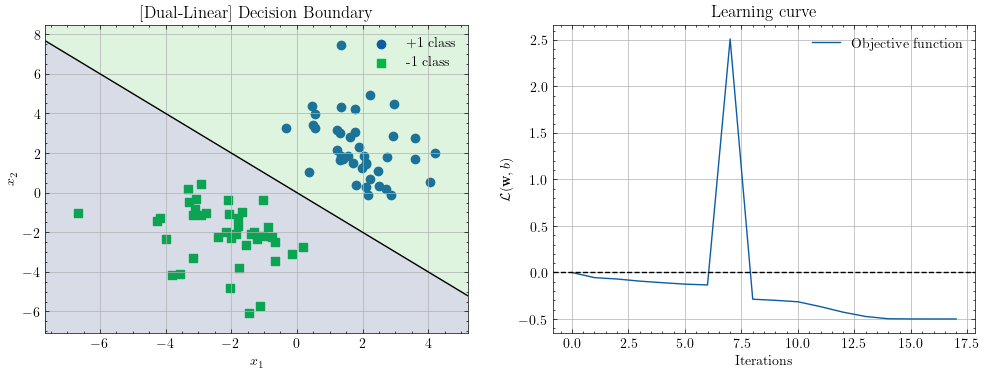

In [71]:

# 2) Dual SVM demonstration (Linear Kernel)
dual_svm_lin = DualSVM(C=1.0, kernel_func=linear_kernel, max_iter=10_000, bb_steps=True, verbose=False)
dual_svm_lin.fit(X, y)

pred_lin = dual_svm_lin.predict(X)
acc_lin = accuracy(y, pred_lin)
alpha_sv = get_support_vectors_dual(dual_svm_lin.alpha)
w_sv = dual_svm_lin.recover_w()
b_sv = dual_svm_lin.get_b()
margin_sv = dual_svm_lin.get_margin()

print("[DUAL-LINEAR] Accuracy:", acc_lin)
print("[DUAL-LINEAR] Final dual obj:", dual_svm_lin.obj_history[-1])

print("[DUAL-LINEAR] #SupportVectors:", alpha_sv.shape[0])
print("[DUAL-LINEAR] Weights:", w_sv)
print("[DUAL-LINEAR] Bias:", b_sv)
print("[DUAL-LINEAR] Margin:", margin_sv)

plt.figure()

plot_decision_boundary_2D(dual_svm_lin, X, y, title="[Dual-Linear] Decision Boundary", dual=True)


[DUAL-RBF] Weights: [33.71678818 39.64372096]
[DUAL-RBF] Bias: -0.03346646836769116
[DUAL-RBF] Margin: 0.01921497731131308
[DUAL-RBF] Accuracy: 1.0
[DUAL-RBF] Final dual obj: -7.347328546304134
[DUAL-RBF] #SupportVectors: 33


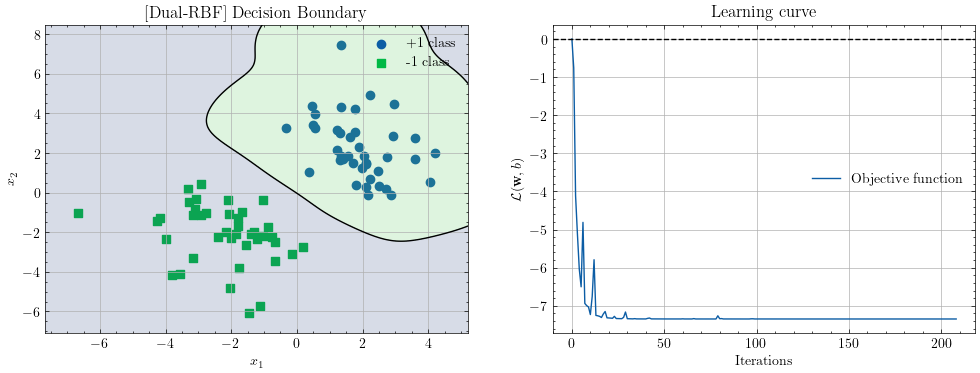

In [72]:

# 3) Dual SVM demonstration (RBF Kernel)
rbf = make_rbf_kernel(gamma=0.5)  # example gamma
dual_svm_rbf = DualSVM(C=1.0, kernel_func=rbf, max_iter=10_000, bb_steps=True, verbose=False)
dual_svm_rbf.fit(X, y)

pred_rbf = dual_svm_rbf.predict(X)
acc_rbf = accuracy(y, pred_rbf)
w_rbf = dual_svm_rbf.recover_w()
b_rbf = dual_svm_rbf.get_b()
margin_rbf = dual_svm_rbf.get_margin()
print("[DUAL-RBF] Weights:", w_rbf)
print("[DUAL-RBF] Bias:", b_rbf)
print("[DUAL-RBF] Margin:", margin_rbf)
print("[DUAL-RBF] Accuracy:", acc_rbf)
print("[DUAL-RBF] Final dual obj:", dual_svm_rbf.obj_history[-1])
alpha_sv_rbf = get_support_vectors_dual(dual_svm_rbf.alpha)
print("[DUAL-RBF] #SupportVectors:", len(alpha_sv_rbf))

plot_decision_boundary_2D(dual_svm_rbf, X, y, title="[Dual-RBF] Decision Boundary", dual=True)


[DUAL-LAPLACIAN] Accuracy: 1.0
[DUAL-LAPLACIAN] Final dual obj: -5.482049922629017
[DUAL-LAPLACIAN] #SupportVectors: 37


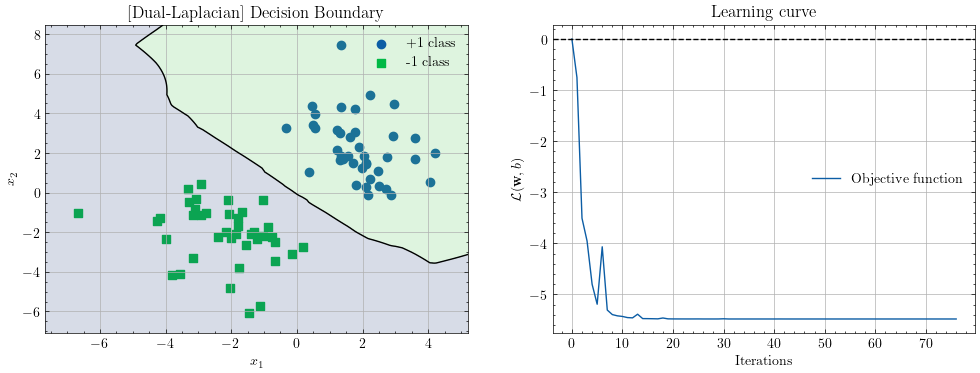

In [73]:
laplacian = make_laplacian_kernel(gamma=0.5)
dual_svm_lap = DualSVM(C=1.0, kernel_func=laplacian, max_iter=1000, bb_steps=True, verbose=False)
dual_svm_lap.fit(X, y)
pred_lap = dual_svm_lap.predict(X)
acc_lap = accuracy(y, pred_lap)
print("[DUAL-LAPLACIAN] Accuracy:", acc_lap)
print("[DUAL-LAPLACIAN] Final dual obj:", dual_svm_lap.obj_history[-1])
alpha_sv_lap = get_support_vectors_dual(dual_svm_lap.alpha)
print("[DUAL-LAPLACIAN] #SupportVectors:", len(alpha_sv_lap))
plot_decision_boundary_2D(dual_svm_lap, X, y, title="[Dual-Laplacian] Decision Boundary", dual=True)

[DUAL-POLY] Accuracy: 1.0
[DUAL-POLY] Final dual obj: -0.21903524123082338
[DUAL-POLY] #SupportVectors: 4


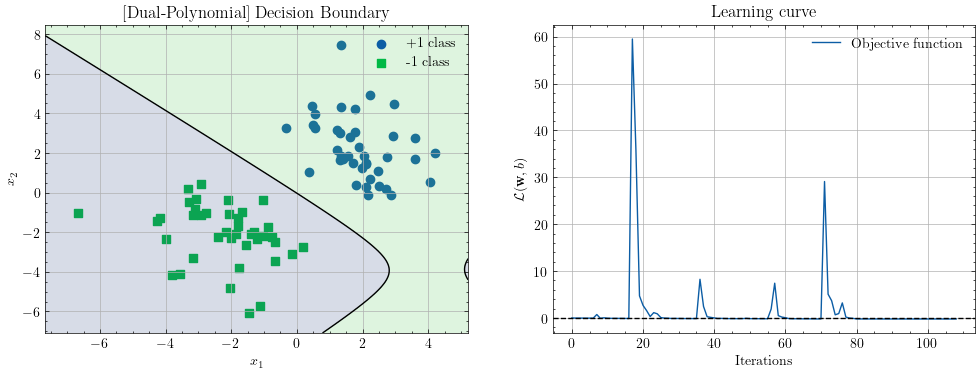

In [ ]:
poly = make_polynomial_kernel(degree=2, coef0=1)
dual_svm_poly = DualSVM(C=1.0, kernel_func=poly, max_iter=1000, bb_steps=True, verbose=False)
dual_svm_poly.fit(X, y)
pred_poly = dual_svm_poly.predict(X)
acc_poly = accuracy(y, pred_poly)
print("[DUAL-POLY] Accuracy:", acc_poly)
print("[DUAL-POLY] Final dual obj:", dual_svm_poly.obj_history[-1])
alpha_sv_poly = get_support_vectors_dual(dual_svm_poly.alpha)
print("[DUAL-POLY] #SupportVectors:", len(alpha_sv_poly))

plot_decision_boundary_2D(dual_svm_poly, X, y, title="[Dual-Polynomial] Decision Boundary", dual=True)